<a href="https://colab.research.google.com/github/fergonzalvo/ISSD_PH/blob/main/%E2%9A%A1Gonzalvo_Fernando_PH_TP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP1 PROCESAMIENTO DEL HABLA: webscrapping

**Crea una copia de este notebook en tu google colab**

**Renombra el notebook con el siguiente formato APELLIDO_NOMBRE_PH_TP1.ipynb**

**[Fernando Gonzalvo]**


* Resolver las consignas comentando el código fuente, indicando desde dónde fue extraido o generado.

* Explicar y justificar cada paso realizado usando los bloques de texto.

* Publique enlace público a su notebook en google colab y también enlace a su repositorio github de la materia.


## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.



## 1- Webscrapping

Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

No puedes repetir ni usar ni el mismo texto ni la misma web que otra persona quien ya entregó en el foro.

Abajo añade los bloques de código y texto necesarios. Explica paso a paso como descargaste el texto de tu interés.


In [1]:
import requests
from bs4 import BeautifulSoup

sitio = "https://www.marxists.org/espanol/king/1963/agosto28.htm"
respuesta = requests.get(sitio)
respuesta.encoding = 'latin-1'#IMPORTANTE A LA HORA DE LEER TILDES Y VIRGULILLAS
soup = BeautifulSoup(respuesta.text, 'html.parser')


todos_los_parrafos = [p.get_text(strip=True) for p in soup.find_all("p") if p.get_text(strip=True)]#buscamos todos los bloques de texto (<p>)correspondientes a parrafo

indice_inicio = 0
for i, texto in enumerate(todos_los_parrafos):#iteramos para buscar el índice exacto donde empieza el saludo oficial del discurso
    if "Estoy orgulloso de reunirme con ustedes hoy" in texto:
        indice_inicio = i
        break
discurso = todos_los_parrafos[indice_inicio:]#nos quedamos únicamente con los párrafos del discurso real descartando lo anterior

print(f"Cantidad de párrafos reales del discurso detectados: {len(discurso)}")
print("primer parrafo del texto a trabajar:")
print(discurso[0] if discurso else "No se encontraron párrafos")


Cantidad de párrafos reales del discurso detectados: 27
primer parrafo del texto a trabajar:
Estoy orgulloso de reunirme con ustedes hoy, en la que será ante la historia la mayor manifestación por la libertad en la historia de nuestro país.Hace cien años, un gran estadounidense, cuya simbólica sombra nos cobija hoy, firmó la Proclama de la emancipación. Este trascendental decreto significó como un gran rayo de luz y de esperanza para millones de esclavos negros, chamuscados en las llamas de una marchita injusticia. Llegó como un precioso amanecer al final de una larga noche de cautiverio. Pero, cien años después, el negro aún no es libre; cien años después, la vida del negro es aún tristemente lacerada por las esposas de la segregación y las cadenas de la discriminación; cien años después, el negro vive en una isla solitaria en medio de un inmenso océano de prosperidad material; cien años después, el negro todavía languidece en las esquinas de la sociedad estadounidense y se encuentra 

## 2- Preprocesamiento

### 2.1 Muestra las stop words que tenga tu texto.

In [2]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('punkt') #entorno

texto_unido = " ".join(discurso)
palabras = word_tokenize(texto_unido.lower())#minusculas con .lower

stopwords_es = set(stopwords.words('spanish'))# la lista oficial de stopwords en español


stopwords_presentes = set([word for word in palabras if word in stopwords_es])#busco las stopwords_es en palabras

print("total sw")
print(len(stopwords_presentes))

print("algunas sw")
print(list(stopwords_presentes)[:20])

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


total sw
90
algunas sw
['mis', 'serían', 'del', 'habrá', 'nos', 'lo', 'sentido', 'donde', 'por', 'seremos', 'más', 'nuestro', 'ni', 'no', 'cual', 'mi', 'nuestra', 'e', 'su', 'las']


### 2.2 Quita las stop-words, caracteres extraños del texto. Utiliza el texto restante para crear una nube de palabras. Usa la biblioteca worldcloud de python.

### 2.3 Usando el texto que conseguiste en el punto 1).


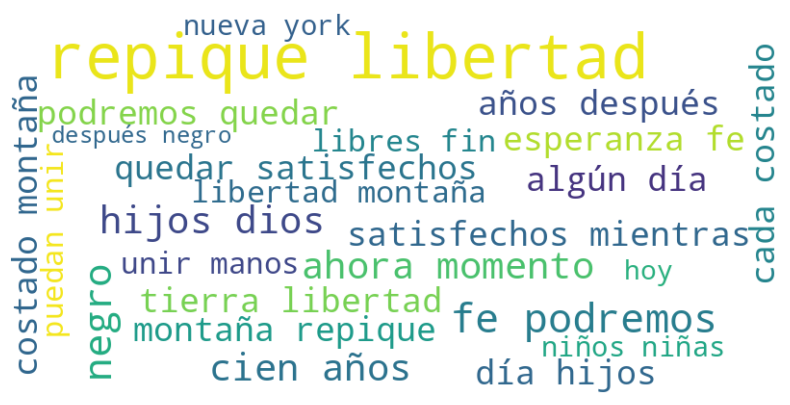

In [3]:
import re  # Se importa la librería para expresiones regulares
from wordcloud import WordCloud  # Se importa la clase WordCloud para generar la imagen
import matplotlib.pyplot as plt  # Se importa pyplot para visualizar la nube de palabras

texto_solo_letras = re.sub(r'[^a-záéíóúñÑ\s]', '', texto_unido.lower()) # Se dejan únicamente letras en español y espacios

palabras = texto_solo_letras.split() # Se divide el texto en una lista de palabras individuales

palabras_limpias = [word for word in palabras if word not in stopwords_es] # Se conservan solo las palabras que no son stop-words

texto_final = " ".join(palabras_limpias) # Se unen las palabras filtradas en un solo string de texto continuo

nube = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=25
    ).generate(texto_final) # Se crea el objeto WordCloud con el texto procesado y se configura la cantidad de palabras con max_word


plt.figure(figsize=(10, 5)) # Se define el tamaño de la figura para la imagen
plt.imshow(nube, interpolation='bilinear') # Se renderiza la imagen de la nube de palabras
plt.axis("off") # Se ocultan los ejes para mejorar la presentación visual
plt.show() # Se despliega la imagen final en el entorno de ejecución


#### 2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.


In [13]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer


documentos_parrafos = discurso#usamos directamente la lista de párrafos ('discurso') como corpus, siendo este el conjunto
vectorizer = CountVectorizer(stop_words=list(stopwords_es), token_pattern=r'(?u)\b[a-zA-ZáéíóúÁÉÍÓÚñÑ]+\b')#se utiliza regex

matriz_dtm = vectorizer.fit_transform(documentos_parrafos)#se transforma la lista de párrafos en la matriz documento-vocabulario

vocabulario = vectorizer.get_feature_names_out()
df_matriz = pd.DataFrame(matriz_dtm.toarray(), columns=vocabulario)#obtenemos el vocabulario y lo convertimos a un df

longitud_vocabulario = len(vocabulario)#len para saber cuantas palabras

print(f"Total de términos únicos extraídos: {longitud_vocabulario} palabras.\n")#resultados
print("matriz=")
df_matriz


Total de términos únicos extraídos: 524 palabras.

matriz=


/usr/local/lib/python3.13/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'd', 'debido', 'didn', 'doesn', 'don', 'gracias', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'm', 'mustn', 'pesar', 're', 's', 'shan', 'shouldn', 't', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(


,acelerar,actos,adelante,afirmamos,agua,aguarda,alabama,aldea,algunos,alleghenies,...,vigorizante,violencia,vive,vivirá,vivirán,volver,votar,ya,yo,york
0,1,1,1,1,1,1,2,1,3,1,...,1,1,1,1,1,2,2,1,1,2
1,1,1,1,1,1,1,2,1,3,1,...,1,1,1,1,1,2,2,1,1,2
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
8,0,1,1,0,0,1,0,0,0,0,...,0,1,0,0,0,1,0,1,0,0
9,1,0,0,1,1,0,2,1,3,1,...,0,0,0,1,1,1,2,0,1,2



#### 2.3.2 Determina la longitud de tu vocabulario.

In [15]:
print("longitud vocabulario:")
print(f"total de {longitud_vocabulario} palabras únicas.") # Se despliega el total de términos únicos extraídos

longitud vocabulario:
total de 524 palabras únicas.



#### 2.3.3. Aplica TF-IDF a tu matriz documento-vocabulario

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd


vectorizador_tfidf = TfidfVectorizer(stop_words=list(stopwords_es))#, token_pattern=r'(?u)\b[a-zA-ZáéíóúÁÉÍÓÚñÑ]{3,}\b')#instanciamos el vectorizador TF-IDF con stop words y filtro de longitud (mínimo 3 letras)

matriz_tfidf = vectorizador_tfidf.fit_transform(discurso)#creacion de matriz

vocabulario_tfidf = vectorizador_tfidf.get_feature_names_out()
df_tfidf = pd.DataFrame(matriz_tfidf.toarray(), columns=vocabulario_tfidf)#se extraen las palabras unicas y se crea una matriz con los valores

print("---matriz--")
print(df_tfidf.head())

print("\n---palabras con mayor peso---")
pesos_promedio = df_tfidf.mean(axis=0).sort_values(ascending=False)
print(pesos_promedio.head(10))


---matriz--
       1963  acelerar     actos  adelante  afirmamos      agua   aguarda  \
0  0.023665  0.019169  0.023665  0.023665   0.021872  0.021872  0.023665   
1  0.023665  0.019169  0.023665  0.023665   0.021872  0.021872  0.023665   
2  0.000000  0.000000  0.000000  0.000000   0.000000  0.000000  0.000000   
3  0.000000  0.000000  0.000000  0.000000   0.000000  0.000000  0.000000   
4  0.000000  0.000000  0.000000  0.000000   0.000000  0.000000  0.000000   

    alabama     aldea   algunos  ...  vigorizante  violencia      vive  \
0  0.038339  0.019169  0.065617  ...     0.023665   0.023665  0.023665   
1  0.038339  0.019169  0.065617  ...     0.023665   0.023665  0.023665   
2  0.000000  0.000000  0.000000  ...     0.000000   0.000000  0.000000   
3  0.000000  0.000000  0.000000  ...     0.000000   0.000000  0.090244   
4  0.000000  0.000000  0.000000  ...     0.000000   0.000000  0.000000   

     vivirá   vivirán    volver     votar        ya        yo      york  
0  0.021872 

/usr/local/lib/python3.13/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'debido', 'didn', 'doesn', 'don', 'gracias', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 'pesar', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(


Explica el formato de tu matriz resultante: documentos, vocabulario, tamaño. Brinda tus conclusiones:

la primer matriz tiene como columnas a cada uno de los terminos y como filas, a los corpus, aquí,todos los parrafos!

y la segunda, es una matriz de 1x10, donde los nombres son los indices, los valores, son el promedio de la suma de los valores de tf-idf de cada termino en cada documento(cada parrafo)

# Conclusiones

Agregue aquí sus conclusiones sobre este trabajo práctico. Puede ser también parte del texto que posteará en el foro.

es un trabajo excelente para poder meter manos en la masa con metodos, funciones y limpieza de texto, para obtener resultados  que nos brinden informacion relevante de un conjunto de documentos.


# Anexo, código de ejemplo del uso de wordcloud

Instalar e importar la librería

In [7]:
# instalar wordcloud
!pip install wordcloud


In [8]:

# Importar librerías
from wordcloud import WordCloud
import matplotlib.pyplot as plt


In [9]:

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Crear un objeto WordCloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)


Mostramos la imagen generada

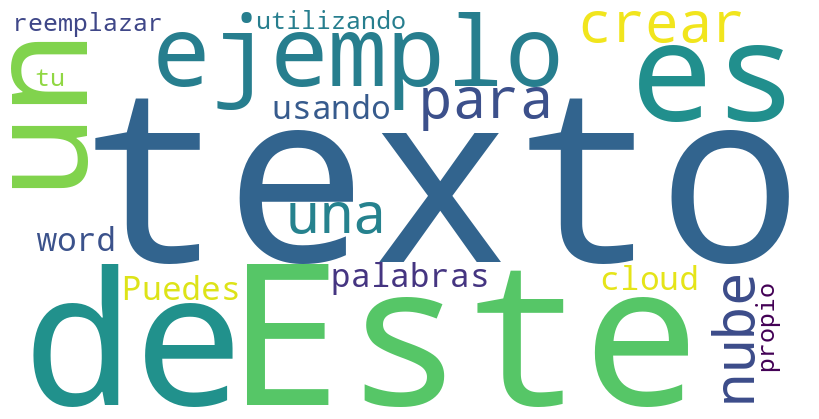

In [10]:

# mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

Modificamos el ejemplo anterior agregando palabras en español que no queremos que considere para crear la nube de palabras. Estas son las stop_words



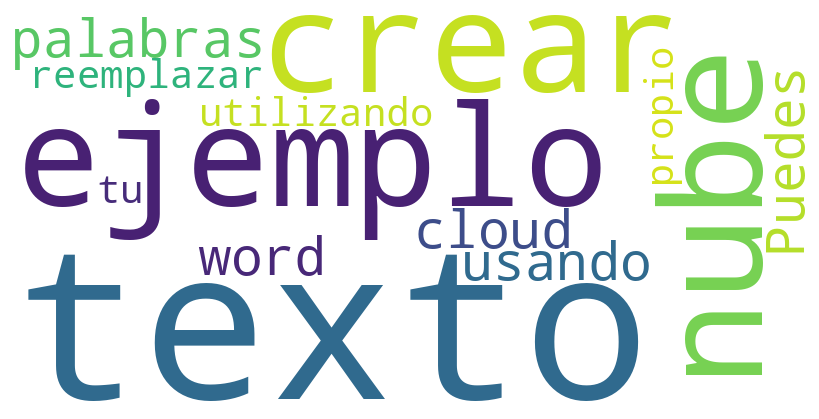

In [11]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Definir stopwords en español
stopwords_es = set(STOPWORDS)
stopwords_es.update(["con", "que", "los", "para", "un", "una", "el", "la", "en", "y", "o", "de", "a", "se", "es", "al", "como", "por", "no", "su", "más", "pero", "si", "este", "esta", "eso", "esa", "todo", "todos", "todas", "cada", "cual", "cualquier", "algo", "alguna", "algún", "ningún", "ninguna", "ninguno", "otro", "otros", "otras", "sobre", "entre", "durante", "desde", "hasta", "también", "así", "mismo", "misma", "mismo", "misma", "tan", "tanto", "tanta", "muy", "poco", "poca", "poco", "nada", "solo", "sola", "solo", "sola", "siempre", "nunca", "jamás", "casi", "aproximadamente", "cerca", "lejos", "antes", "después", "ahora", "hoy", "ayer", "mañana", "luego", "mientras", "mientras tanto", "después de", "antes de", "durante", "sin", "aunque", "a pesar de", "debido a", "gracias a", "por qué", "cómo", "dónde", "cuándo", "quién", "qué", "cuál"])

# Crear un objeto WordCloud con stopwords en español
wordcloud = WordCloud(width=800, height=400, background_color="white", stopwords=stopwords_es).generate(text)

# Mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()
